In [26]:
# Cell Summary: Import libraries and set up global configurations.
import pandas as pd
import numpy as np
import ast
import scipy.sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, normalize, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import re
import os
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted', zero_division=0),
    'f1_score': make_scorer(f1_score, average='weighted', zero_division=0)
}
N_SPLITS = 5
cv_strategy = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
print(f"Libraries imported and setup complete. Default CV strategy: StratifiedKFold(n_splits={N_SPLITS})")

Libraries imported and setup complete. Default CV strategy: StratifiedKFold(n_splits=5)


In [27]:
# Cell Summary: Load the primary dataset containing textual features and disease names.
try:
    df_text = pd.read_csv("disease_features.csv")
    print("Textual data loaded successfully.")
    print(f"Shape: {df_text.shape}")
except FileNotFoundError:
    print("Error: disease_features.csv not found. Please ensure it's in the correct directory.")
    df_text = None
except Exception as e:
    print(f"An error occurred while loading disease_features.csv: {e}")
    df_text = None

Textual data loaded successfully.
Shape: (25, 5)


In [28]:
# Cell Summary: Define functions to parse and clean stringified lists/dicts into space-separated strings.
def parse_and_join_list(text):
    try:
        parsed = ast.literal_eval(str(text))
        if isinstance(parsed, list):
            cleaned_items = [
                str(item).strip().lower().replace(" ", "_")
                for item in parsed if item is not None and isinstance(item, str) and item.strip()
            ]
            return ' '.join(cleaned_items)
        else:
            return ""
    except (ValueError, SyntaxError, TypeError):
        return ""

def parse_dict_keys_to_string(text):
    try:
        parsed = ast.literal_eval(str(text))
        if isinstance(parsed, dict):
            cleaned_keys = [
                re.sub(r'\s+', '_', key).strip().lower()
                for key in parsed.keys() if isinstance(key, str) and key.strip()
             ]
            return ' '.join(cleaned_keys)
        else:
            return ""
    except (ValueError, SyntaxError, TypeError):
        return ""

print("Parsing and joining functions defined with text cleaning.")

Parsing and joining functions defined with text cleaning.


In [29]:
# Cell Summary: Apply parsing functions to create combined text columns for TF-IDF.
if df_text is not None:
    df_text['Risk Factors Text'] = df_text['Risk Factors'].apply(parse_and_join_list)
    df_text['Symptoms Text'] = df_text['Symptoms'].apply(parse_and_join_list)
    df_text['Signs Text'] = df_text['Signs'].apply(parse_and_join_list)
    df_text['Subtypes Text'] = df_text['Subtypes'].apply(parse_dict_keys_to_string)
    print("Parsing, cleaning, and joining applied to create text columns.")
else:
    print("Skipping text processing as df_text was not loaded.")

Parsing, cleaning, and joining applied to create text columns.


In [30]:
# Cell Summary: Initialize separate TF-IDF vectorizers for each feature type.
if df_text is not None:
    tfidf_vectorizers = {
        'Risk Factors': TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95),
        'Symptoms': TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95),
        'Signs': TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95),
        'Subtypes': TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)
    }
    print("Separate TfidfVectorizers initialized for each text column.")
else:
    tfidf_vectorizers = None
    print("Skipping TF-IDF vectorizer initialization.")

Separate TfidfVectorizers initialized for each text column.


In [31]:
# Cell Summary: Apply TF-IDF vectorization separately to each text column.
tfidf_matrices = {}
feature_names_tfidf = {}

if df_text is not None and tfidf_vectorizers is not None:
    try:
        for col_name, text_col in [
            ('Risk Factors', 'Risk Factors Text'),
            ('Symptoms', 'Symptoms Text'),
            ('Signs', 'Signs Text'),
            ('Subtypes', 'Subtypes Text')
        ]:
            tfidf_matrices[col_name] = tfidf_vectorizers[col_name].fit_transform(df_text[text_col])
            feature_names_tfidf[col_name] = tfidf_vectorizers[col_name].get_feature_names_out()
            print(f"  - Applied TF-IDF to {col_name}: Shape={tfidf_matrices[col_name].shape}")
        print("\nTF-IDF vectorization applied successfully using separate vectorizers.")
    except Exception as e:
        print(f"An error occurred during TF-IDF vectorization: {e}")
        tfidf_matrices = {}
else:
    print("Skipping TF-IDF vectorization as df_text or vectorizers are not available.")

  - Applied TF-IDF to Risk Factors: Shape=(25, 27)
  - Applied TF-IDF to Symptoms: Shape=(25, 18)
  - Applied TF-IDF to Signs: Shape=(25, 6)
  - Applied TF-IDF to Subtypes: Shape=(25, 2)

TF-IDF vectorization applied successfully using separate vectorizers.


In [32]:
# Cell Summary: Combine individual TF-IDF matrices and apply L2 normalization.
X_tfidf = None
tfidf_feature_names_combined = []

if tfidf_matrices and len(tfidf_matrices) == 4:
    X_tfidf_unnormalized = scipy.sparse.hstack(
        [tfidf_matrices[col] for col in ['Risk Factors', 'Symptoms', 'Signs', 'Subtypes']],
        format='csr'
    )
    X_tfidf = normalize(X_tfidf_unnormalized, norm='l2', axis=1)
    tfidf_feature_names_combined = \
        [f"Risk_{name}" for name in feature_names_tfidf['Risk Factors']] + \
        [f"Symptom_{name}" for name in feature_names_tfidf['Symptoms']] + \
        [f"Sign_{name}" for name in feature_names_tfidf['Signs']] + \
        [f"Subtype_{name}" for name in feature_names_tfidf['Subtypes']]
    print(f"Combined and Normalized TF-IDF matrix shape: {X_tfidf.shape}")
    print(f"Total number of combined TF-IDF features: {len(tfidf_feature_names_combined)}")
else:
    print("Skipping TF-IDF combination/normalization as individual matrices are incomplete.")

Combined and Normalized TF-IDF matrix shape: (25, 53)
Total number of combined TF-IDF features: 53


In [33]:
# Cell Summary: Load the one-hot encoded feature dataset.
try:
    df_onehot = pd.read_csv("encoded_output2.csv")
    print("One-hot encoded data loaded successfully.")
    print(f"Shape: {df_onehot.shape}")
except FileNotFoundError:
    print("Error: encoded_output2.csv not found. Please ensure it's in the correct directory.")
    df_onehot = None
except Exception as e:
    print(f"An error occurred while loading encoded_output2.csv: {e}")
    df_onehot = None

One-hot encoded data loaded successfully.
Shape: (25, 497)


In [34]:
# Cell Summary: Define and apply a function to categorize diseases based on keywords.
def categorize_disease(name):
    if not isinstance(name, str):
        return "Other"
    name = name.lower()
    if any(keyword in name for keyword in ["stroke", "alzheimer", "epilepsy", "sclerosis", "migraine", "pituitary"]):
        return "Neurological/Endocrine"
    elif any(keyword in name for keyword in ["asthma", "copd", "pneumonia", "pulmonary embolism", "tuberculosis"]):
        return "Respiratory/Infectious"
    elif any(keyword in name for keyword in ["heart", "cardio", "coronary", "atrial fibrillation", "aortic dissection", "hypertension", "hyperlipidemia"]):
        return "Cardiovascular"
    elif any(keyword in name for keyword in ["diabetes", "adrenal insufficiency", "thyroid"]):
        return "Endocrine"
    elif any(keyword in name for keyword in ["gastritis", "ulcer", "gastro-oesophageal", "gastrointestinal bleeding"]):
        return "Gastrointestinal"
    else:
        return "Other"

if df_text is not None:
    df_text['Category'] = df_text['Disease'].apply(categorize_disease)
    print("Disease categories derived using keyword matching.")
    print("\nCategory Counts:")
    print(df_text['Category'].value_counts())
    try:
        df_text[['Disease', 'Category']].to_csv('disease_category_mapping_generated.csv', index=False)
        print("\nDisease-Category mapping saved to 'disease_category_mapping_generated.csv'")
    except Exception as e:
        print(f"\nError saving category mapping: {e}")
else:
    print("Skipping category generation as df_text is not loaded.")

Disease categories derived using keyword matching.

Category Counts:
Category
Cardiovascular            7
Neurological/Endocrine    6
Respiratory/Infectious    5
Gastrointestinal          4
Endocrine                 3
Name: count, dtype: int64

Disease-Category mapping saved to 'disease_category_mapping_generated.csv'


In [35]:
# Cell Summary: Prepare and align the one-hot encoded matrix according to the text data order.
X_onehot = None
onehot_feature_names = []

if df_text is not None and df_onehot is not None:
    reference_diseases = df_text['Disease'].tolist()
    try:
        df_onehot_aligned = df_onehot.set_index('Disease').reindex(reference_diseases).reset_index()
        if df_onehot_aligned.drop('Disease', axis=1).isnull().any().any():
             print("Warning: Alignment introduced NaNs in feature columns. Filling with 0.")
             df_onehot_aligned = df_onehot_aligned.fillna(0)

        X_onehot_dense = df_onehot_aligned.drop('Disease', axis=1).values
        X_onehot_dense = X_onehot_dense.astype(float)
        onehot_feature_names = df_onehot_aligned.drop('Disease', axis=1).columns.tolist()
        X_onehot = X_onehot_dense

        print("One-hot feature matrix (X_onehot) prepared and aligned.")
        print(f"X_onehot shape: {X_onehot.shape}")
        print(f"Number of one-hot features: {len(onehot_feature_names)}")

    except KeyError:
        print("Error: 'Disease' column not found in one-hot CSV or mismatch during alignment.")
        X_onehot = None
    except Exception as e:
        print(f"An error occurred during one-hot data preparation: {e}")
        X_onehot = None
elif df_text is None:
    print("Skipping one-hot preparation as df_text is missing.")
elif df_onehot is None:
    print("Skipping one-hot preparation as df_onehot is missing.")

if X_tfidf is not None and X_onehot is not None:
    if X_tfidf.shape[0] != X_onehot.shape[0]:
        print(f"CRITICAL WARNING: Row count mismatch! X_tfidf ({X_tfidf.shape[0]}) vs X_onehot ({X_onehot.shape[0]}).")
    else:
        print("Row counts match between TF-IDF and One-Hot matrices.")

One-hot feature matrix (X_onehot) prepared and aligned.
X_onehot shape: (25, 496)
Number of one-hot features: 496
Row counts match between TF-IDF and One-Hot matrices.


In [36]:
# Cell Summary: Compare TF-IDF and One-Hot matrices in terms of shape, features, and sparsity.
print("\n--- Matrix Comparison ---")
results_comparison = {}

def calculate_sparsity(matrix):
    if isinstance(matrix, (np.ndarray, pd.DataFrame)):
        non_zeros = np.count_nonzero(matrix)
        total = matrix.size
    elif scipy.sparse.issparse(matrix):
        non_zeros = matrix.nnz
        total = matrix.shape[0] * matrix.shape[1]
    else: return np.nan
    if total == 0: return np.nan
    return 1.0 - (non_zeros / float(total))

if X_tfidf is not None:
    sparsity_tfidf = calculate_sparsity(X_tfidf)
    print(f"TF-IDF Matrix:\n  - Shape: {X_tfidf.shape}\n  - Sparsity: {sparsity_tfidf:.4f} ({sparsity_tfidf*100:.2f}%)\n  - Number of Features: {X_tfidf.shape[1]}")
    results_comparison['TF-IDF'] = {'Shape': X_tfidf.shape, 'Sparsity': sparsity_tfidf, 'Features': X_tfidf.shape[1]}

if X_onehot is not None:
    sparsity_onehot = calculate_sparsity(X_onehot)
    print(f"\nOne-Hot Matrix:\n  - Shape: {X_onehot.shape}\n  - Sparsity: {sparsity_onehot:.4f} ({sparsity_onehot*100:.2f}%)\n  - Number of Features: {X_onehot.shape[1]}")
    results_comparison['One-Hot'] = {'Shape': X_onehot.shape, 'Sparsity': sparsity_onehot, 'Features': X_onehot.shape[1]}

if 'TF-IDF' in results_comparison and 'One-Hot' in results_comparison:
     print("\nComparison Summary:")
     print(f"  - Feature Count: TF-IDF ({results_comparison['TF-IDF']['Features']}) vs One-Hot ({results_comparison['One-Hot']['Features']})")
     print(f"  - Sparsity: TF-IDF ({results_comparison['TF-IDF']['Sparsity']:.2%}) vs One-Hot ({results_comparison['One-Hot']['Sparsity']:.2%}).")
     if results_comparison['TF-IDF']['Sparsity'] > results_comparison['One-Hot']['Sparsity']: print("     -> TF-IDF matrix is sparser.")
     else: print("     -> One-Hot matrix is sparser (or equally sparse).")
     print("  - Unique Features: TF-IDF features represent weighted term importance. One-Hot explicitly represents predefined features.")
elif 'TF-IDF' in results_comparison: print("\nOnly TF-IDF matrix available for comparison.")
elif 'One-Hot' in results_comparison: print("\nOnly One-Hot matrix available for comparison.")
else: print("\nNo matrices available for comparison.")


--- Matrix Comparison ---
TF-IDF Matrix:
  - Shape: (25, 53)
  - Sparsity: 0.8860 (88.60%)
  - Number of Features: 53

One-Hot Matrix:
  - Shape: (25, 496)
  - Sparsity: 0.9534 (95.34%)
  - Number of Features: 496

Comparison Summary:
  - Feature Count: TF-IDF (53) vs One-Hot (496)
  - Sparsity: TF-IDF (88.60%) vs One-Hot (95.34%).
     -> One-Hot matrix is sparser (or equally sparse).
  - Unique Features: TF-IDF features represent weighted term importance. One-Hot explicitly represents predefined features.


In [37]:
# Cell Summary: Set up data for dimensionality reduction (scaling One-Hot, preparing dense TF-IDF).
n_components_vis = 2
X_tfidf_array = None
X_onehot_scaled = None

if X_tfidf is not None:
    try:
        X_tfidf_array = X_tfidf.toarray()
        print("Created dense array from sparse TF-IDF for PCA.")
    except MemoryError:
        print("Warning: Could not create dense TF-IDF array due to memory constraints. PCA on TF-IDF will be skipped.")
        X_tfidf_array = None
    except Exception as e:
        print(f"Error converting TF-IDF to dense array: {e}")
        X_tfidf_array = None

if X_onehot is not None:
    try:
        scaler = StandardScaler()
        X_onehot_scaled = scaler.fit_transform(X_onehot)
        print("Applied StandardScaler to One-Hot data.")
    except Exception as e:
        print(f"Error scaling One-Hot data: {e}")
        X_onehot_scaled = None

if df_text is not None and 'Category' in df_text.columns:
    category_labels = df_text['Category'].values
    print("Category labels obtained for plotting.")
else:
    category_labels = None
    print("Category labels not available for plotting.")

Created dense array from sparse TF-IDF for PCA.
Applied StandardScaler to One-Hot data.
Category labels obtained for plotting.


In [38]:
# Cell Summary: Apply PCA and TruncatedSVD to TF-IDF and One-Hot matrices.
results_dim_red = {}

if X_tfidf is not None:
    try:
        svd_tfidf = TruncatedSVD(n_components=n_components_vis, random_state=42)
        tfidf_svd_result = svd_tfidf.fit_transform(X_tfidf)
        results_dim_red['SVD_TFIDF'] = {'components': tfidf_svd_result, 'variance': svd_tfidf.explained_variance_ratio_}
        print(f"Applied SVD to TF-IDF (Sparse). Explained Var: {results_dim_red['SVD_TFIDF']['variance'].sum():.4f}")
    except Exception as e: print(f"Error applying SVD to TF-IDF: {e}")

    if X_tfidf_array is not None:
        try:
            pca_tfidf = PCA(n_components=n_components_vis, random_state=42)
            tfidf_pca_result = pca_tfidf.fit_transform(X_tfidf_array)
            results_dim_red['PCA_TFIDF'] = {'components': tfidf_pca_result, 'variance': pca_tfidf.explained_variance_ratio_}
            print(f"Applied PCA to TF-IDF (Dense). Explained Var: {results_dim_red['PCA_TFIDF']['variance'].sum():.4f}")
        except Exception as e: print(f"Error applying PCA to dense TF-IDF: {e}")
    else: print("Skipping PCA on TF-IDF (dense array not available).")
else: print("Skipping Dimensionality Reduction on TF-IDF (matrix not available).")

if X_onehot is not None:
    try:
        svd_onehot = TruncatedSVD(n_components=n_components_vis, random_state=42)
        onehot_svd_result = svd_onehot.fit_transform(X_onehot)
        results_dim_red['SVD_OneHot'] = {'components': onehot_svd_result, 'variance': svd_onehot.explained_variance_ratio_}
        print(f"\nApplied SVD to One-Hot. Explained Var: {results_dim_red['SVD_OneHot']['variance'].sum():.4f}")
    except Exception as e: print(f"Error applying SVD to One-Hot: {e}")

    if X_onehot_scaled is not None:
        try:
            pca_onehot = PCA(n_components=n_components_vis, random_state=42)
            onehot_pca_result = pca_onehot.fit_transform(X_onehot_scaled)
            results_dim_red['PCA_OneHot'] = {'components': onehot_pca_result, 'variance': pca_onehot.explained_variance_ratio_}
            print(f"Applied PCA to One-Hot (Scaled). Explained Var: {results_dim_red['PCA_OneHot']['variance'].sum():.4f}")
        except Exception as e: print(f"Error applying PCA to scaled One-Hot: {e}")
    else: print("Skipping PCA on One-Hot (scaled data not available).")
else: print("Skipping Dimensionality Reduction on One-Hot (matrix not available).")

Applied SVD to TF-IDF (Sparse). Explained Var: 0.1334
Applied PCA to TF-IDF (Dense). Explained Var: 0.1971

Applied SVD to One-Hot. Explained Var: 0.1144
Applied PCA to One-Hot (Scaled). Explained Var: 0.2001



--- Explained Variance Comparison (Top 2 Components) ---
SVD_OneHot: 0.1144 (Comp1: 0.0225, Comp2: 0.0919)
SVD_TFIDF: 0.1334 (Comp1: 0.0309, Comp2: 0.1025)
PCA_TFIDF: 0.1971 (Comp1: 0.1026, Comp2: 0.0944)
PCA_OneHot: 0.2001 (Comp1: 0.1081, Comp2: 0.0920)

Method capturing most variance in 2 components: PCA_OneHot (0.2001)


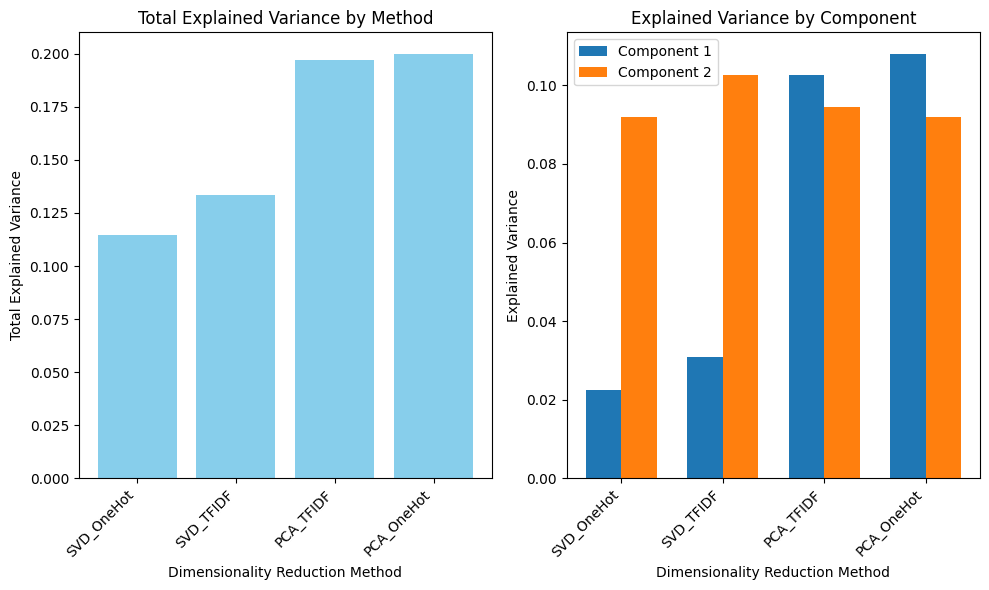

In [39]:
# Cell Summary: Compare explained variance ratios across dimensionality reduction methods with sorting and visualization.
print("\n--- Explained Variance Comparison (Top 2 Components) ---")
if results_dim_red:
    variances = {method: data['variance'].sum() for method, data in results_dim_red.items()}
    
    sorted_methods = sorted(variances.items(), key=lambda x: x[1])
    
    for method, total_variance in sorted_methods:
        data = results_dim_red[method]
        print(f"{method}: {total_variance:.4f} (Comp1: {data['variance'][0]:.4f}, Comp2: {data['variance'][1]:.4f})")
    
    if variances:
        best_method = max(variances, key=variances.get)
        print(f"\nMethod capturing most variance in 2 components: {best_method} ({variances[best_method]:.4f})")
        
    plt.figure(figsize=(10, 6))
    
    plt.subplot(1, 2, 1)
    methods = [method for method, _ in sorted_methods]
    total_variances = [variance for _, variance in sorted_methods]
    
    plt.bar(methods, total_variances, color='skyblue')
    plt.title('Total Explained Variance by Method')
    plt.xlabel('Dimensionality Reduction Method')
    plt.ylabel('Total Explained Variance')
    plt.xticks(rotation=45, ha='right')
    
    plt.subplot(1, 2, 2)
    comp1_variances = [results_dim_red[method]['variance'][0] for method, _ in sorted_methods]
    comp2_variances = [results_dim_red[method]['variance'][1] for method, _ in sorted_methods]
    
    x = np.arange(len(methods))
    width = 0.35
    
    plt.bar(x - width/2, comp1_variances, width, label='Component 1')
    plt.bar(x + width/2, comp2_variances, width, label='Component 2')
    
    plt.title('Explained Variance by Component')
    plt.xlabel('Dimensionality Reduction Method')
    plt.ylabel('Explained Variance')
    plt.xticks(x, methods, rotation=45, ha='right')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
else:
    print("\nNo dimensionality reduction results available to compare.")

In [40]:
# Cell Summary: Define a function for plotting 2D reduced data, colored by category.
def plot_reduced_dimensions(X_reduced, category_labels, title):
    if X_reduced is None or category_labels is None:
        print(f"Skipping plot '{title}' due to missing data.")
        return
    if X_reduced.shape[0] != len(category_labels):
        print(f"Skipping plot '{title}': Mismatch points ({X_reduced.shape[0]}) vs labels ({len(category_labels)}).")
        return
    if X_reduced.shape[1] < 2:
        print(f"Skipping plot '{title}': Need >= 2 dimensions, found {X_reduced.shape[1]}.")
        return

    plt.figure(figsize=(12, 8))
    unique_categories = sorted(pd.Series(category_labels).unique())
    palette = sns.color_palette("viridis", n_colors=len(unique_categories))

    scatter = sns.scatterplot(
        x=X_reduced[:, 0], y=X_reduced[:, 1], hue=category_labels,
        hue_order=unique_categories, palette=palette, s=60, alpha=0.8
    )
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend(title='Disease Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

print("Visualization function defined.")

Visualization function defined.



--- Visualization of Reduced Dimensions ---


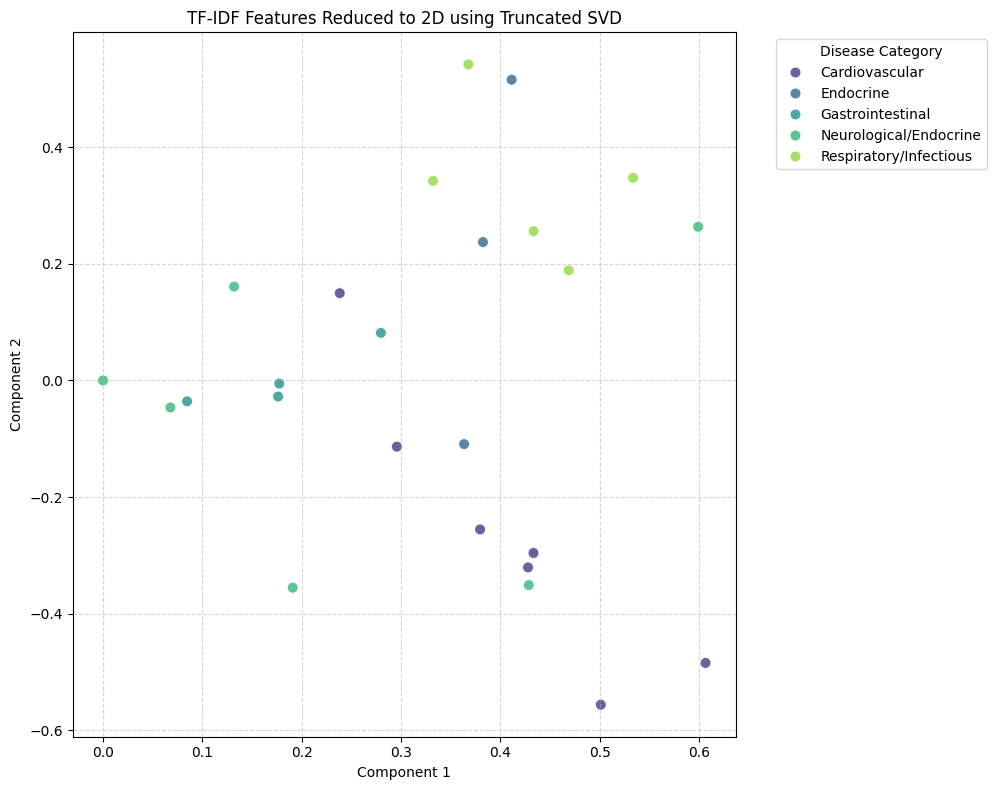

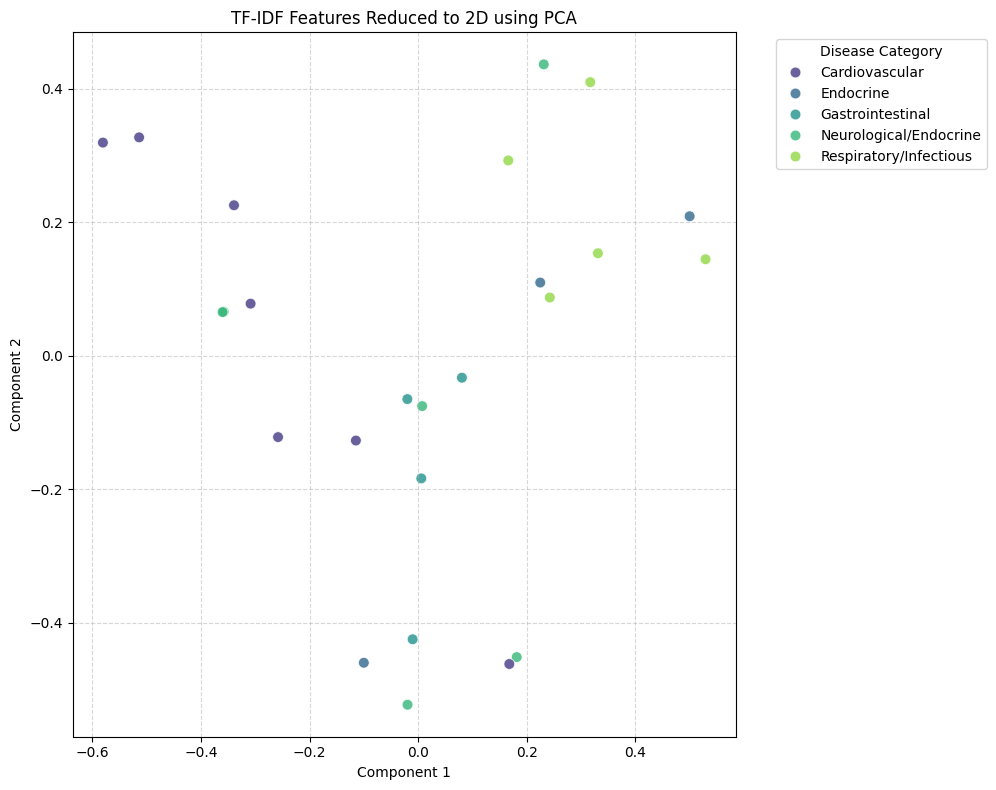

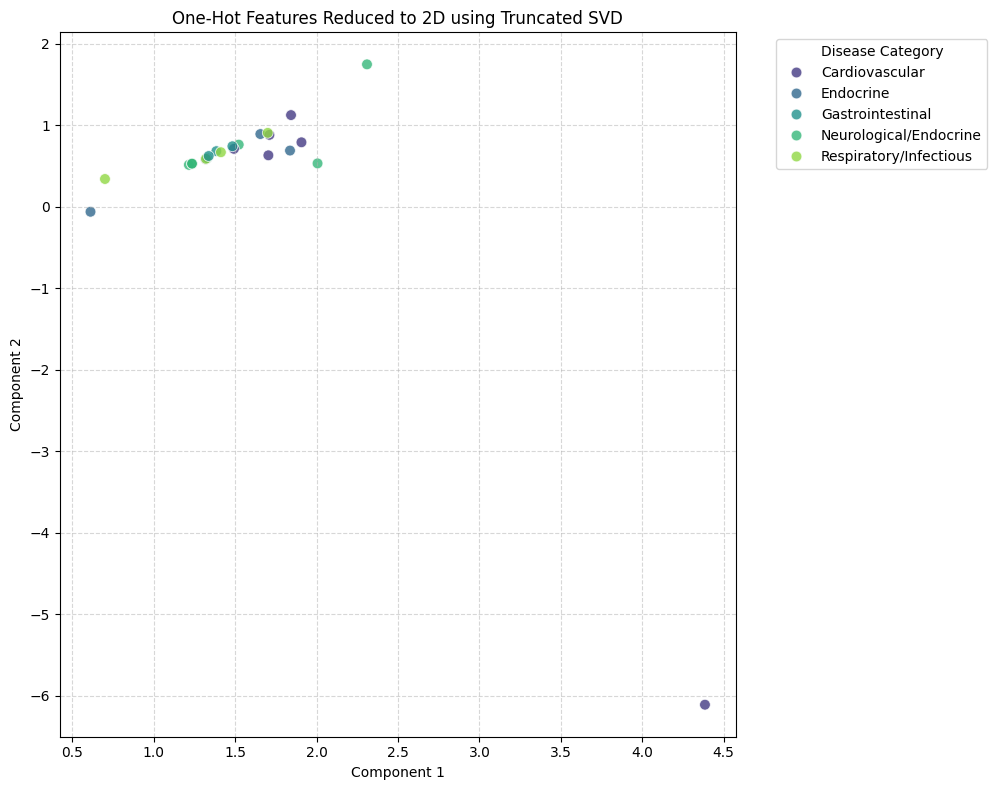

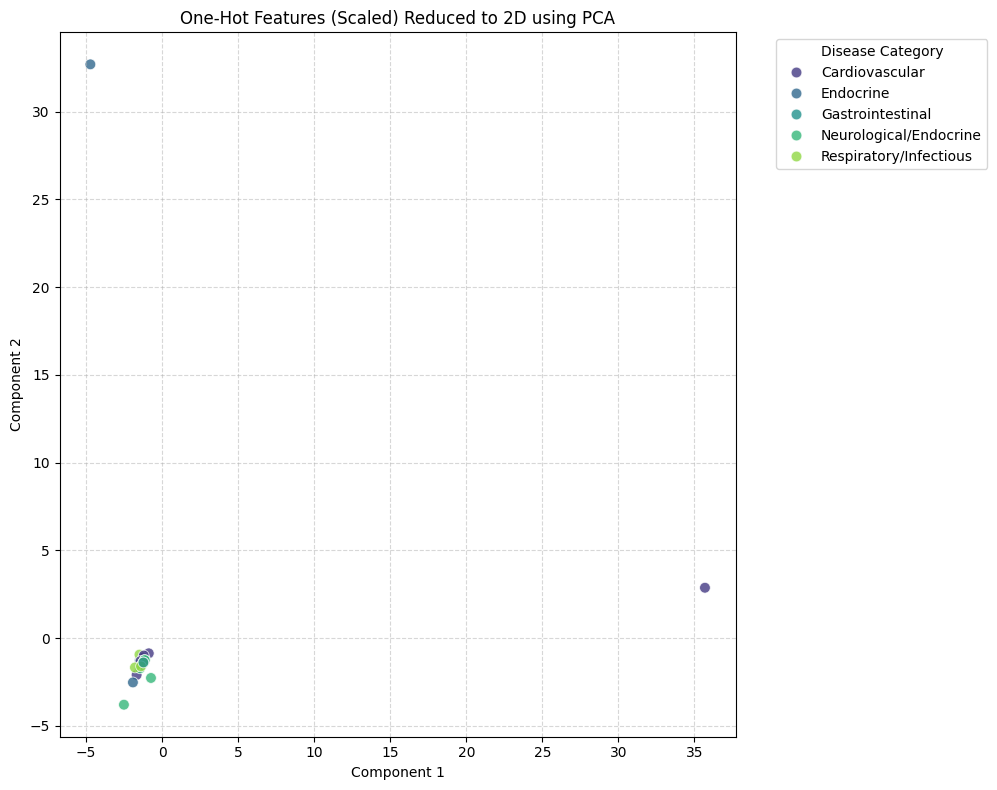


--- Seperable Clusters Observation ---
TF-IDF produces more seperable clusters than One-Hot
TF-IDF reduced to 2D using Truncated SVD produces more seperable clusters than using PCA as visible in the visualizations


In [41]:
# Cell Summary: Visualize the 2D reduced data from PCA and SVD, colored by category.
print("\n--- Visualization of Reduced Dimensions ---")
if category_labels is not None:
    if 'SVD_TFIDF' in results_dim_red: plot_reduced_dimensions(results_dim_red['SVD_TFIDF']['components'], category_labels, 'TF-IDF Features Reduced to 2D using Truncated SVD')
    if 'PCA_TFIDF' in results_dim_red: plot_reduced_dimensions(results_dim_red['PCA_TFIDF']['components'], category_labels, 'TF-IDF Features Reduced to 2D using PCA')
    if 'SVD_OneHot' in results_dim_red: plot_reduced_dimensions(results_dim_red['SVD_OneHot']['components'], category_labels, 'One-Hot Features Reduced to 2D using Truncated SVD')
    if 'PCA_OneHot' in results_dim_red: plot_reduced_dimensions(results_dim_red['PCA_OneHot']['components'], category_labels, 'One-Hot Features (Scaled) Reduced to 2D using PCA')
else: print("Skipping visualization as category labels are missing.")

print("\n--- Seperable Clusters Observation ---")
print("TF-IDF produces more seperable clusters than One-Hot")
print("TF-IDF reduced to 2D using Truncated SVD produces more seperable clusters than using PCA as visible in the visualizations")

In [42]:
# Cell Summary: Prepare data for modeling by filtering based on category sample size for StratifiedKFold.
y_cat = None
y_cat_encoded = None
mask = None
X_tfidf_filtered = None
X_onehot_filtered = None
y_filtered = None

if df_text is not None and 'Category' in df_text.columns and X_tfidf is not None and X_onehot is not None:
    y_cat = df_text['Category'].values
    label_encoder = LabelEncoder()
    y_cat_encoded = label_encoder.fit_transform(y_cat)
    print("Original Category Counts (Encoded):\n", pd.Series(y_cat_encoded).value_counts())

    category_counts = pd.Series(y_cat_encoded).value_counts()
    valid_labels = category_counts[category_counts >= N_SPLITS].index
    print(f"\nCategories with at least {N_SPLITS} samples (Encoded): {valid_labels.tolist()}")

    mask = pd.Series(y_cat_encoded).isin(valid_labels).values

    if mask.sum() > 0:
        X_tfidf_filtered = X_tfidf[mask]
        X_onehot_filtered = X_onehot[mask]
        y_filtered = y_cat_encoded[mask]
        print(f"\nData filtered to include {mask.sum()} samples from {len(valid_labels)} categories.")
        print(f"  - X_tfidf_filtered shape: {X_tfidf_filtered.shape}")
        print(f"  - X_onehot_filtered shape: {X_onehot_filtered.shape}")
        print(f"  - y_filtered shape: {y_filtered.shape}")
        print("\nFiltered Category Counts (Encoded):\n", pd.Series(y_filtered).value_counts())
    else:
        print(f"\nWarning: No categories found with at least {N_SPLITS} samples. Cannot proceed with StratifiedKFold modeling.")
else:
    print("Skipping data filtering: Prerequisite data missing.")

Original Category Counts (Encoded):
 0    7
3    6
4    5
2    4
1    3
Name: count, dtype: int64

Categories with at least 5 samples (Encoded): [0, 3, 4]

Data filtered to include 18 samples from 3 categories.
  - X_tfidf_filtered shape: (18, 53)
  - X_onehot_filtered shape: (18, 496)
  - y_filtered shape: (18,)

Filtered Category Counts (Encoded):
 0    7
3    6
4    5
Name: count, dtype: int64


In [43]:
# Cell Summary: Apply dimensionality reduction (PCA for KNN, SVD for LR) to the filtered data.
n_components_pca = 17
n_components_svd = 17
X_tfidf_model_knn = None
X_onehot_model_knn = None
X_tfidf_model_lr = None
X_onehot_model_lr = None
print(f"\nPreparing FILTERED data for KNN using PCA (n_components={n_components_pca})...")
if X_tfidf_filtered is not None:
    try:
        n_comp_actual = min(n_components_pca, X_tfidf_filtered.shape[1]-1, X_tfidf_filtered.shape[0]-1)
        pca_tfidf_model = PCA(n_components=n_comp_actual, random_state=42)
        X_tfidf_model_knn = pca_tfidf_model.fit_transform(X_tfidf_filtered.toarray())
        print(f"  - Filtered TF-IDF data for KNN prepared. Shape: {X_tfidf_model_knn.shape}")
    except Exception as e: print(f"  - Error preparing filtered TF-IDF for KNN: {e}")
else: print("  - Skipping TF-IDF preparation for KNN (filtered source missing).")
if X_onehot_filtered is not None:
    try:
        n_comp_actual = min(n_components_pca, X_onehot_filtered.shape[1]-1, X_onehot_filtered.shape[0]-1)
        pca_onehot_model = PCA(n_components=n_comp_actual, random_state=42)
        X_onehot_model_knn = pca_onehot_model.fit_transform(X_onehot_filtered)
        print(f"  - Filtered One-Hot data for KNN prepared. Shape: {X_onehot_model_knn.shape}")
    except Exception as e: print(f"  - Error preparing filtered One-Hot for KNN: {e}")
else: print("  - Skipping One-Hot preparation for KNN (filtered source missing).")
print(f"\nPreparing FILTERED data for LR using TruncatedSVD (n_components={n_components_svd})...")
if X_tfidf_filtered is not None:
    try:
        n_comp_actual = min(n_components_svd, X_tfidf_filtered.shape[1]-1, X_tfidf_filtered.shape[0]-1)
        svd_tfidf_model = TruncatedSVD(n_components=n_comp_actual, random_state=42)
        X_tfidf_model_lr = svd_tfidf_model.fit_transform(X_tfidf_filtered)
        print(f"  - Filtered TF-IDF data for LR prepared. Shape: {X_tfidf_model_lr.shape}")
    except Exception as e: print(f"  - Error preparing filtered TF-IDF for LR: {e}")
else: print("  - Skipping TF-IDF preparation for LR (filtered source missing).")
if X_onehot_filtered is not None:
    try:
        n_comp_actual = min(n_components_svd, X_onehot_filtered.shape[1]-1, X_onehot_filtered.shape[0]-1)
        svd_onehot_model = TruncatedSVD(n_components=n_comp_actual, random_state=42)
        X_onehot_model_lr = svd_onehot_model.fit_transform(X_onehot_filtered)
        print(f"  - Filtered One-Hot data for LR prepared. Shape: {X_onehot_model_lr.shape}")
    except Exception as e: print(f"  - Error preparing filtered One-Hot for LR: {e}")
else: print("  - Skipping One-Hot preparation for LR (filtered source missing).")
print("\nData versions for KNN (PCA reduced) and LR (SVD reduced) prepared.")


Preparing FILTERED data for KNN using PCA (n_components=17)...
  - Filtered TF-IDF data for KNN prepared. Shape: (18, 17)
  - Filtered One-Hot data for KNN prepared. Shape: (18, 17)

Preparing FILTERED data for LR using TruncatedSVD (n_components=17)...
  - Filtered TF-IDF data for LR prepared. Shape: (18, 17)
  - Filtered One-Hot data for LR prepared. Shape: (18, 17)

Data versions for KNN (PCA reduced) and LR (SVD reduced) prepared.


In [44]:
# Cell Summary: Perform cross-validation for KNN on filtered, SVD-reduced data.
knn_results = []
k_values = [3, 5, 7]
metrics_knn = ['euclidean', 'manhattan', 'cosine']
if y_filtered is None or (X_tfidf_model_knn is None and X_onehot_model_knn is None):
    print("\nSkipping KNN Cross-Validation: Filtered data not available.")
else:
    print(f"\n--- Running KNN Cross-Validation on Filtered Data (Target: Categories, CV: StratifiedKFold {N_SPLITS} splits) ---")
    for encoding_name, X_knn in [('TF-IDF', X_tfidf_model_knn), ('One-Hot', X_onehot_model_knn)]:
        if X_knn is None:
            print(f"\nSkipping KNN for {encoding_name}: Reduced data not available.")
            continue
        print(f"\n--- KNN on {encoding_name} (SVD Reduced) ---")
        min_samples_in_fold = min(np.bincount(y_filtered)) # Smallest class size
        min_train_samples = X_knn.shape[0] - (X_knn.shape[0] // N_SPLITS) # Approx train size

        for metric_name in metrics_knn:
            for k in k_values:
                if k >= min_train_samples:
                    print(f"  Skipping KNN: k={k}, Metric={metric_name} on {encoding_name} (k >= ~{min_train_samples} training samples)")
                    continue

                print(f"  Training KNN: k={k}, Metric={metric_name} on {encoding_name}...")
                knn = KNeighborsClassifier(n_neighbors=k, metric=metric_name, n_jobs=-1)
                pipeline = Pipeline([('knn', knn)])
                try:
                    cv_results = cross_validate(pipeline, X_knn, y_filtered, cv=cv_strategy, scoring=scoring, n_jobs=-1)
                    result_row = {
                        'Encoding': encoding_name, 'Model': 'KNN', 'k': k, 'Metric': metric_name,
                        'Avg Accuracy': np.mean(cv_results['test_accuracy']), 'Std Accuracy': np.std(cv_results['test_accuracy']),
                        'Avg Precision': np.mean(cv_results['test_precision']), 'Avg Recall': np.mean(cv_results['test_recall']),
                        'Avg F1-score': np.mean(cv_results['test_f1_score']), 'Std F1-score': np.std(cv_results['test_f1_score'])
                    }
                    knn_results.append(result_row)
                    print(f"    -> Avg F1: {result_row['Avg F1-score']:.4f} (+/- {result_row['Std F1-score']:.4f})")
                except ValueError as ve: print(f"    -> Error during CV for k={k}, Metric={metric_name} on {encoding_name}: {ve}")
                except Exception as e: print(f"    -> General Error during CV for k={k}, Metric={metric_name} on {encoding_name}: {e}")
    knn_results_df = pd.DataFrame(knn_results)
    print("\nKNN Cross-Validation on Filtered Data Complete.")


--- Running KNN Cross-Validation on Filtered Data (Target: Categories, CV: StratifiedKFold 5 splits) ---

--- KNN on TF-IDF (SVD Reduced) ---
  Training KNN: k=3, Metric=euclidean on TF-IDF...
    -> Avg F1: 0.4422 (+/- 0.1814)
  Training KNN: k=5, Metric=euclidean on TF-IDF...
    -> Avg F1: 0.7528 (+/- 0.2226)
  Training KNN: k=7, Metric=euclidean on TF-IDF...
    -> Avg F1: 0.5856 (+/- 0.1955)
  Training KNN: k=3, Metric=manhattan on TF-IDF...
    -> Avg F1: 0.5778 (+/- 0.2999)
  Training KNN: k=5, Metric=manhattan on TF-IDF...
    -> Avg F1: 0.3750 (+/- 0.3689)
  Training KNN: k=7, Metric=manhattan on TF-IDF...
    -> Avg F1: 0.3622 (+/- 0.2242)
  Training KNN: k=3, Metric=cosine on TF-IDF...
    -> Avg F1: 0.7022 (+/- 0.1654)
  Training KNN: k=5, Metric=cosine on TF-IDF...
    -> Avg F1: 0.7556 (+/- 0.3174)
  Training KNN: k=7, Metric=cosine on TF-IDF...
    -> Avg F1: 0.5389 (+/- 0.3151)

--- KNN on One-Hot (SVD Reduced) ---
  Training KNN: k=3, Metric=euclidean on One-Hot...
  

In [45]:
# Performing 5-fold cross-validation for Logistic Regression on the FILTERED encodings.
# Using the filtered sparse TF-IDF and filtered dense One-Hot matrices.
lr_results = []
if y_filtered is None or (X_tfidf_model_lr is None and X_onehot_model_lr is None):
     print("\nSkipping Logistic Regression Cross-Validation: Filtered data not available.")
else:
    print(f"\n--- Running Logistic Regression Cross-Validation on Filtered Data (Target: Categories, CV: StratifiedKFold {N_SPLITS} splits) ---")
    for encoding_name, X_lr in [('TF-IDF', X_tfidf_model_lr), ('One-Hot', X_onehot_model_lr)]:
         if X_lr is None:
             print(f"\nSkipping Logistic Regression for {encoding_name}: Filtered data not available.")
             continue
         print(f"\n--- Logistic Regression on {encoding_name} ---")
         if encoding_name == 'One-Hot':
              pipeline_lr = Pipeline([
                  ('logreg', LogisticRegression(random_state=42, max_iter=2000, multi_class='auto', C=5, class_weight='balanced', penalty='l1', solver='liblinear'))
              ])
         else: 
              pipeline_lr = Pipeline([
                  ('logreg', LogisticRegression(random_state=42, max_iter=1000, multi_class='auto', C=5, penalty='l1', solver='liblinear'))
              ])
         try:
            cv_results_lr = cross_validate(
                pipeline_lr,
                X_lr, 
                y_filtered,
                cv=cv_strategy,
                scoring=scoring,
                n_jobs=-1 
            )
            result_row_lr = {
                'Encoding': encoding_name,
                'Model': 'Logistic Regression',
                'k': None, 
                'Metric': None, 
                'Avg Accuracy': np.mean(cv_results_lr['test_accuracy']),
                'Std Accuracy': np.std(cv_results_lr['test_accuracy']),
                'Avg Precision': np.mean(cv_results_lr['test_precision']),
                'Avg Recall': np.mean(cv_results_lr['test_recall']),
                'Avg F1-score': np.mean(cv_results_lr['test_f1_score']),
                'Std F1-score': np.std(cv_results_lr['test_f1_score'])
            }
            lr_results.append(result_row_lr)
            print(f"  -> Avg F1: {result_row_lr['Avg F1-score']:.4f} (+/- {result_row_lr['Std F1-score']:.4f})")
         except Exception as e:
            print(f"  -> Error during Logistic Regression CV on {encoding_name}: {e}")
    lr_results_df = pd.DataFrame(lr_results)
    print("\nLogistic Regression Cross-Validation on Filtered Data Complete.")
    # display(lr_results_df.sort_values(by='Avg F1-score', ascending=False))


--- Running Logistic Regression Cross-Validation on Filtered Data (Target: Categories, CV: StratifiedKFold 5 splits) ---

--- Logistic Regression on TF-IDF ---
  -> Avg F1: 0.7056 (+/- 0.1644)

--- Logistic Regression on One-Hot ---
  -> Avg F1: 0.4478 (+/- 0.3217)

Logistic Regression Cross-Validation on Filtered Data Complete.



--- Visual Comparison of Model Performance (Avg Metrics) ---


<Figure size 1500x800 with 0 Axes>

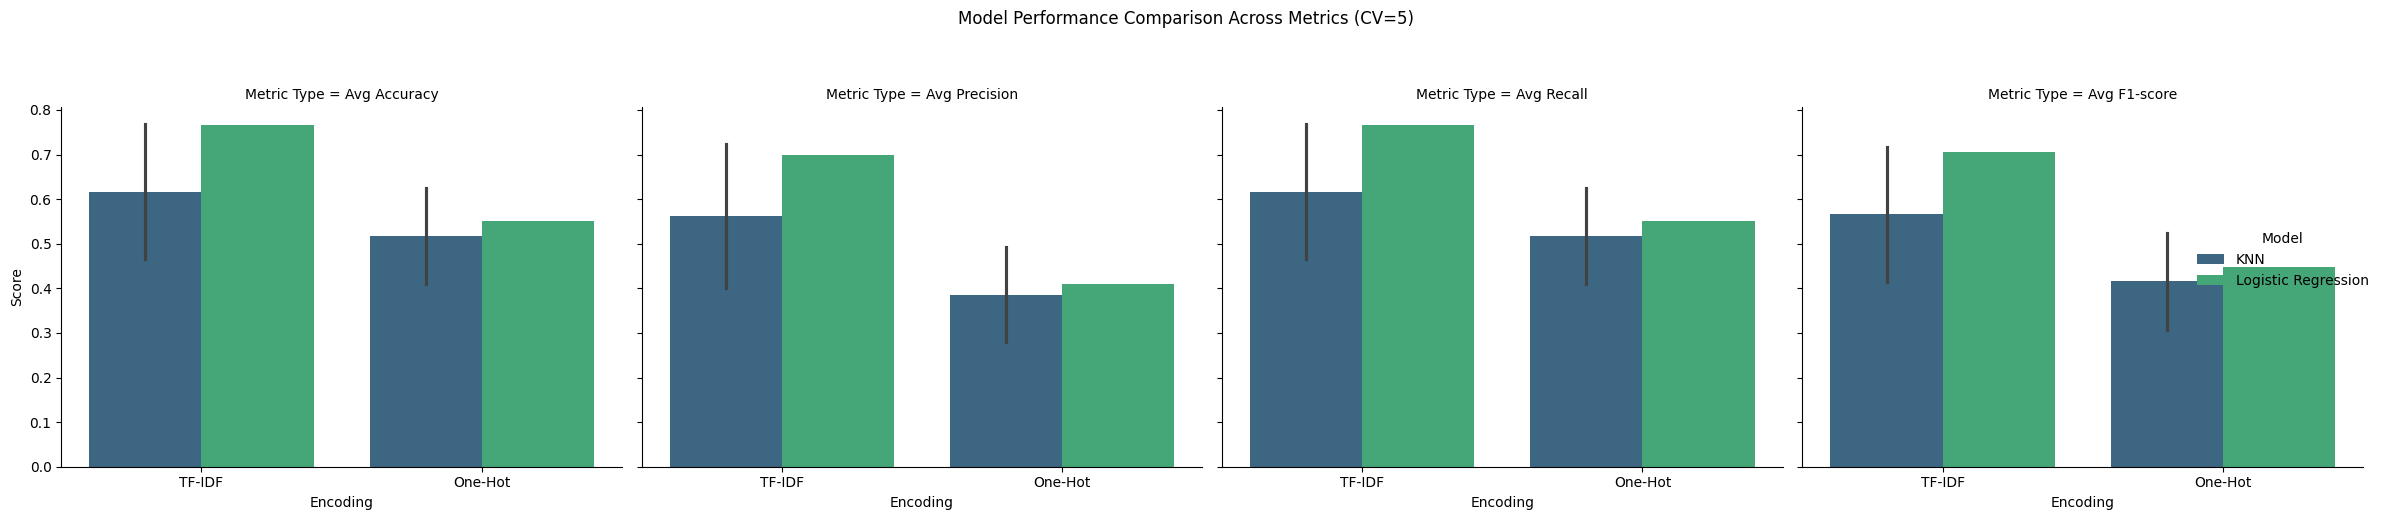

<Figure size 1400x700 with 0 Axes>

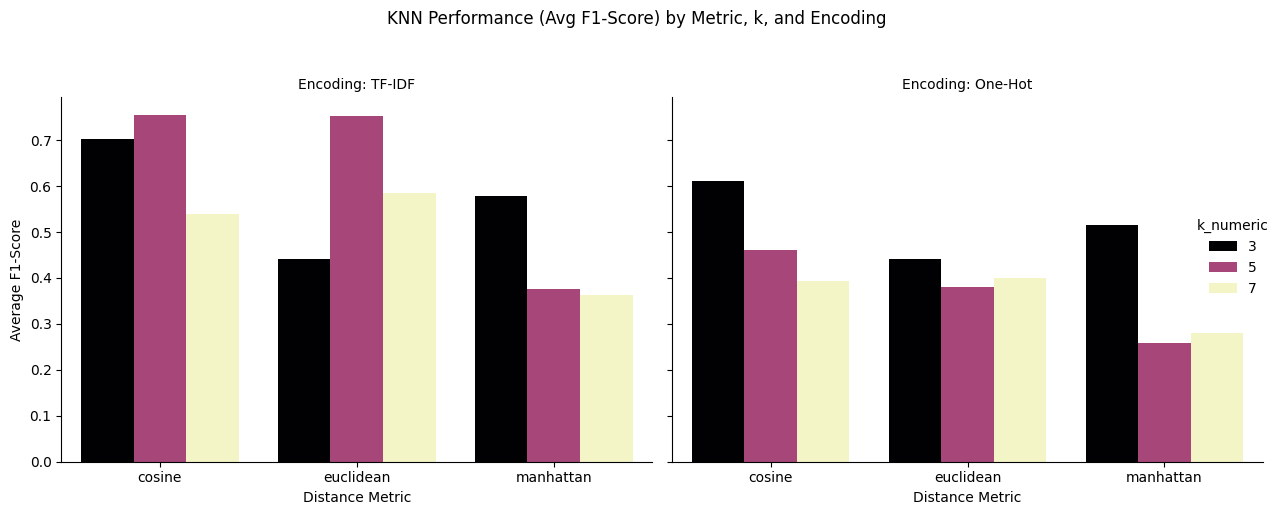

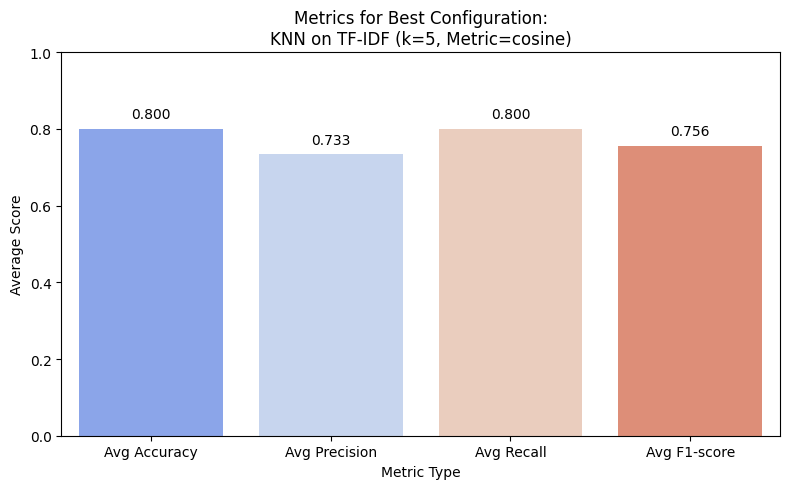


--- Combined Model Performance Results Table (Top 10 by Avg F1-score) ---
--- Target: Disease Categories (Filtered Data, CV: StratifiedKFold 5 splits) ---
  Encoding                Model  k     Metric  Avg Accuracy  Avg Precision  Avg Recall  Avg F1-score
0   TF-IDF                  KNN  5     cosine      0.800000       0.733333    0.800000      0.755556
1   TF-IDF                  KNN  5  euclidean      0.783333       0.791667    0.783333      0.752778
2   TF-IDF  Logistic Regression  -          -      0.766667       0.700000    0.766667      0.705556
3   TF-IDF                  KNN  3     cosine      0.766667       0.691667    0.766667      0.702222
4  One-Hot                  KNN  3     cosine      0.700000       0.572222    0.700000      0.611111
5   TF-IDF                  KNN  7  euclidean      0.650000       0.600000    0.650000      0.585556
6   TF-IDF                  KNN  3  manhattan      0.616667       0.583333    0.616667      0.577778
7   TF-IDF                  KNN  7  

In [46]:
# Cell Summary: Combine, visualize, and display results from KNN and Logistic Regression, reporting all key metrics.
if 'knn_results_df' not in locals(): knn_results_df = pd.DataFrame()
if 'lr_results_df' not in locals(): lr_results_df = pd.DataFrame()

if not knn_results_df.empty or not lr_results_df.empty:
    all_results_df = pd.concat([knn_results_df, lr_results_df], ignore_index=True)
    all_results_df_sorted = all_results_df.sort_values(by='Avg F1-score', ascending=False).reset_index(drop=True)
    all_results_df_sorted['k'] = all_results_df_sorted['k'].fillna('-')
    all_results_df_sorted['Metric'] = all_results_df_sorted['Metric'].fillna('-')

    print("\n--- Visual Comparison of Model Performance (Avg Metrics) ---")

    metrics_to_plot = ['Avg Accuracy', 'Avg Precision', 'Avg Recall', 'Avg F1-score']
    df_melted = all_results_df_sorted.melt(
        id_vars=['Encoding', 'Model', 'k', 'Metric'],
        value_vars=metrics_to_plot,
        var_name='Metric Type',
        value_name='Score'
    )

    plt.figure(figsize=(15, 8))
    sns.catplot(data=df_melted, x='Encoding', y='Score', hue='Model', col='Metric Type',
                kind='bar', palette='viridis', height=5, aspect=1.1, errorbar='sd')
    plt.suptitle(f'Model Performance Comparison Across Metrics (CV={N_SPLITS})', y=1.03)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    knn_results_vis = all_results_df_sorted[all_results_df_sorted['Model'] == 'KNN'].copy()
    if not knn_results_vis.empty:
         knn_results_vis['k_numeric'] = pd.to_numeric(knn_results_vis['k'], errors='coerce').fillna(0)
         plt.figure(figsize=(14, 7))
         g = sns.catplot(data=knn_results_vis, x='Metric', y='Avg F1-score', hue='k_numeric',
                       col='Encoding', kind='bar', palette='magma', height=5, aspect=1.2, errorbar='sd')
         g.fig.suptitle('KNN Performance (Avg F1-Score) by Metric, k, and Encoding', y=1.02)
         g.set_axis_labels("Distance Metric", "Average F1-Score")
         g.set_titles("Encoding: {col_name}")
         plt.tight_layout(rect=[0, 0, 1, 0.98])
         plt.show()

    if not all_results_df_sorted.empty:
        top_config = all_results_df_sorted.iloc[0]
        top_metrics = top_config[metrics_to_plot]
        plt.figure(figsize=(8, 5))
        sns.barplot(x=top_metrics.index, y=top_metrics.values, palette='coolwarm')
        plt.title(f"Metrics for Best Configuration:\n{top_config['Model']} on {top_config['Encoding']}"
                  f"{f' (k={top_config["k"]}, Metric={top_config["Metric"]})' if top_config['Model'] == 'KNN' else ''}")
        plt.xlabel("Metric Type")
        plt.ylabel("Average Score")
        plt.ylim(0, 1.0)
        for i, score in enumerate(top_metrics.values):
            plt.text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom')
        plt.tight_layout()
        plt.show()

    print("\n--- Combined Model Performance Results Table (Top 10 by Avg F1-score) ---")
    print(f"--- Target: Disease Categories (Filtered Data, CV: StratifiedKFold {N_SPLITS} splits) ---")
    display_cols = ['Encoding', 'Model', 'k', 'Metric', 'Avg Accuracy', 'Avg Precision', 'Avg Recall', 'Avg F1-score']
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1200):
        print(all_results_df_sorted[display_cols].head(10))

    try:
        all_results_df_sorted.to_csv("model_evaluation_results_categories.csv", index=False)
        print("\nFull results saved to model_evaluation_results_categories.csv")
    except Exception as e: print(f"\nError saving results to CSV: {e}")

else:
    print("\nNo model evaluation results generated to display or visualize.")
    all_results_df_sorted = pd.DataFrame()

In [47]:
# Cell Summary: Discuss and compare model performance based on visualized and textual results, considering all reported metrics.
print("\n--- Results Comparison Discussion (Predicting Categories) ---")
if not all_results_df_sorted.empty:
    best_model_config = all_results_df_sorted.iloc[0]
    print(f"Best performance observed for predicting categories (based on F1-score):")
    print(f"  - Configuration: {best_model_config['Model']} on {best_model_config['Encoding']}"
          f"{f' (k={best_model_config['k']}, Metric={best_model_config['Metric']})' if best_model_config['Model'] == 'KNN' else ''}")
    print(f"  - Avg F1-score (Weighted): {best_model_config['Avg F1-score']:.4f}")
    print(f"  - Avg Accuracy: {best_model_config['Avg Accuracy']:.4f}")
    print(f"  - Avg Precision: {best_model_config['Avg Precision']:.4f}")
    print(f"  - Avg Recall: {best_model_config['Avg Recall']:.4f}")
    print(f"  - Note: Scores based on filtered dataset (categories >= {N_SPLITS} samples).")

    print("\nKey Comparisons (Averages across metrics):")
    def avg_perf(df_group):
        return df_group[['Avg Accuracy', 'Avg Precision', 'Avg Recall', 'Avg F1-score']].mean()

    print("1. Encoding Method Performance (Average Scores):")
    perf_encoding = all_results_df_sorted.groupby('Encoding').apply(avg_perf)
    print(perf_encoding)

    knn_results_filtered = all_results_df_sorted[all_results_df_sorted['Model'] == 'KNN']
    if not knn_results_filtered.empty:
        print(f"\n2. KNN Distance Metrics Performance (Average Scores):")
        perf_knn_metric = knn_results_filtered.groupby('Metric').apply(avg_perf)
        print(perf_knn_metric.sort_values(by='Avg F1-score', ascending=False))

    print(f"\n3. Model Type Performance (Average Scores):")
    perf_model_type = all_results_df_sorted.groupby('Model').apply(avg_perf)
    print(perf_model_type.sort_values(by='Avg F1-score', ascending=False))

    print("\nOverall Conclusion on Category Prediction:")
    top_f1 = best_model_config['Avg F1-score']
    top_acc = best_model_config['Avg Accuracy']

    if top_f1 > 0.5 or top_acc > 0.5:
         print(f"  - Models show some capability (Top F1: {top_f1:.2f}, Top Acc: {top_acc:.2f}) in distinguishing broader disease categories on the filtered dataset.")
    elif top_f1 > 0 or top_acc > 0:
         print(f"  - Models struggled (Top F1: {top_f1:.2f}, Top Acc: {top_acc:.2f}) to reliably predict categories.")
         print("  - This could be due to the small filtered dataset size, difficulty of category separation with current features, or limitations of the models.")
    else:
         print("  - Models were unable to predict categories effectively (Scores near 0).")
         print("  - This indicates significant challenges with the data or task setup even after filtering.")

else:
    print("No results available to discuss.")
    print("This likely means no disease categories had enough samples (>= 5) for StratifiedKFold.")
    print("Consider reducing n_splits, using KFold, improving categorization, or acquiring more data.")


--- Results Comparison Discussion (Predicting Categories) ---
Best performance observed for predicting categories (based on F1-score):
  - Configuration: KNN on TF-IDF (k=5, Metric=cosine)
  - Avg F1-score (Weighted): 0.7556
  - Avg Accuracy: 0.8000
  - Avg Precision: 0.7333
  - Avg Recall: 0.8000
  - Note: Scores based on filtered dataset (categories >= 5 samples).

Key Comparisons (Averages across metrics):
1. Encoding Method Performance (Average Scores):
          Avg Accuracy  Avg Precision  Avg Recall  Avg F1-score
Encoding                                                       
One-Hot       0.520000       0.387917    0.520000      0.419278
TF-IDF        0.631667       0.575833    0.631667      0.579778

2. KNN Distance Metrics Performance (Average Scores):
           Avg Accuracy  Avg Precision  Avg Recall  Avg F1-score
Metric                                                          
cosine         0.652778       0.559722    0.652778      0.577222
euclidean      0.591667       0

In [48]:
# Cell Summary: Check for necessary CSV files required by the Streamlit application.
required_files = ["model_evaluation_results_categories.csv", "disease_features.csv"]
files_exist = {f: os.path.exists(f) for f in required_files}
if all(files_exist.values()):
    print("Required files for Streamlit app (model_evaluation_results_categories.csv, disease_features.csv) are present.")
else:
    print("Warning: Not all required files for the Streamlit app were found/created.")
    for f, exists in files_exist.items():
        if not exists: print(f"  - {f} is missing.")

Required files for Streamlit app (model_evaluation_results_categories.csv, disease_features.csv) are present.
